In [72]:
import pandas as pd
import numpy as np
import os
d = os.getcwd()+"/"
PATH_RAW = f"{d}/../source"
PATH_DATA = f"{d}/../data"
PATH_OUTPUT = f"{d}/../output"
folder_spec = PATH_RAW

df = pd.read_csv(f"{PATH_DATA}/data_full.csv" , index_col='date')
data = pd.DataFrame()

## NTL Update

In [ ]:
dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)

threshold1 = dfntl['DNBvalue1'].quantile(0.90)
threshold3 = dfntl['DNBvalue3'].quantile(0.90)
sub1 = dfntl[dfntl['DNBvalue1']<threshold1]['DNBvalue1'].mean()
sub3 = dfntl[dfntl['DNBvalue1']<threshold3]['DNBvalue3'].mean()
window = 30


# BY CATEGORY
dfntl['DNBvalue1'] = dfntl['DNBvalue1'].apply(lambda x: sub1 if x > threshold1 else x)
dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue1'].mean()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue1')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl.columns = [ f"ntl1_{col.lower()}_meanw{window}" for col in dfntl.columns ]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )


dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)
dfntl['DNBvalue1'] = dfntl['DNBvalue1'].apply(lambda x: sub1 if x > threshold1 else x)
dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue1'].sum()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue1')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl.columns = [ f"ntl1_{col.lower()}_sumw{window}" for col in dfntl.columns ]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )

dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)
dfntl['DNBvalue3'] = dfntl['DNBvalue3'].apply(lambda x: sub1 if x > threshold3 else x)

dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue3'].mean()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue3')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl.columns = [ f"ntl3_{col.lower()}_meanw{window}" for col in dfntl.columns ]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )

dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)
dfntl['DNBvalue3'] = dfntl['DNBvalue3'].apply(lambda x: sub3 if x > threshold3 else x)

dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue3'].sum()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue3')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl.columns = [ f"ntl3_{col.lower()}_sumw{window}" for col in dfntl.columns ]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )

dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)
dfntl['DNBvalue1'] = dfntl['DNBvalue1'].apply(lambda x: sub1 if x > threshold1 else x)
dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue1'].sum()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue1')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl[f'ntl1_sumw{window}'] = dfntl.mean(axis=1)
dfntl = dfntl[[f'ntl1_sumw{window}']]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )


dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)
dfntl['DNBvalue1'] = dfntl['DNBvalue1'].apply(lambda x: sub1 if x > threshold1 else x)
dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue1'].mean()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue1')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl[f'ntl1_meanw{window}'] = dfntl.mean(axis=1)
dfntl = dfntl[[f'ntl1_meanw{window}']]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )

dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)
dfntl['DNBvalue3'] = dfntl['DNBvalue3'].apply(lambda x: sub3 if x > threshold3 else x)
dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue3'].sum()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue3')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl[f'ntl3_sumw{window}'] = dfntl.mean(axis=1)
dfntl = dfntl[[f'ntl3_sumw{window}']]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )

# BY CATEGORY
dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)
dfntl['DNBvalue3'] = dfntl['DNBvalue3'].apply(lambda x: sub3 if x > threshold3 else x)
dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue3'].mean()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue3')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl[f'ntl3_meanw{window}'] = dfntl.mean(axis=1)
dfntl = dfntl[[f'ntl3_meanw{window}']]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )

window = 90

dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl = dfntl.set_index('date')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl['DNBvalue1'] = dfntl['DNBvalue1'].apply(lambda x: sub1 if x > threshold1 else x)

dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue1'].mean()).reset_index()
dfntl = dfntl.pivot_table(index='date', columns='sector', values='DNBvalue1')

dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl.columns = [ f"ntl1_{col.lower()}_meanw{window}" for col in dfntl.columns ]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )


dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)
dfntl['DNBvalue1'] = dfntl['DNBvalue1'].apply(lambda x: sub1 if x > threshold1 else x)
dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue1'].sum()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue1')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl.columns = [ f"ntl1_{col.lower()}_sumw{window}" for col in dfntl.columns ]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )

dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)
dfntl['DNBvalue3'] = dfntl['DNBvalue3'].apply(lambda x: sub1 if x > threshold3 else x)

dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue3'].mean()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue3')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl.columns = [ f"ntl3_{col.lower()}_meanw{window}" for col in dfntl.columns ]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )

dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)
dfntl['DNBvalue3'] = dfntl['DNBvalue3'].apply(lambda x: sub3 if x > threshold3 else x)

dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue3'].sum()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue3')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl.columns = [ f"ntl3_{col.lower()}_sumw{window}" for col in dfntl.columns ]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )

dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)
dfntl['DNBvalue1'] = dfntl['DNBvalue1'].apply(lambda x: sub1 if x > threshold1 else x)
dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue1'].sum()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue1')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl[f'ntl1_sumw{window}'] = dfntl.mean(axis=1)
dfntl = dfntl[[f'ntl1_sumw{window}']]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )


dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)
dfntl['DNBvalue1'] = dfntl['DNBvalue1'].apply(lambda x: sub1 if x > threshold1 else x)
dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue1'].mean()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue1')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl[f'ntl1_meanw{window}'] = dfntl.mean(axis=1)
dfntl = dfntl[[f'ntl1_meanw{window}']]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )

dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)
dfntl['DNBvalue3'] = dfntl['DNBvalue3'].apply(lambda x: sub3 if x > threshold3 else x)
dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue3'].sum()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue3')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl[f'ntl3_sumw{window}'] = dfntl.mean(axis=1)
dfntl = dfntl[[f'ntl3_sumw{window}']]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )


dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)
dfntl['DNBvalue3'] = dfntl['DNBvalue3'].apply(lambda x: sub3 if x > threshold3 else x)
dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue3'].mean()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue3')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl[f'ntl3_meanw{window}'] = dfntl.mean(axis=1)
dfntl = dfntl[[f'ntl3_meanw{window}']]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )



In [ ]:
metadata = pd.read_csv(f"{PATH_DATA}/meta_full.csv")
for _, row in metadata.iterrows():
    series_name = row['series']
    ticket_name = row['ticket']
    if series_name in data.columns:
        data.rename(columns={series_name: ticket_name}, inplace=True)


df.index = pd.to_datetime(df.index)
data.index = pd.to_datetime(data.index)
df = df.drop( data.columns , axis=1)
df = pd.concat([df, data], axis=1)

In [ ]:
df.to_csv(f"{PATH_DATA}/data_full.csv")

## FULL UPDATE

In [73]:
files = [ file for file in os.listdir(PATH_RAW) if "csv" in file and "ntl_" not in file and "gtrends" not in file ]

df = pd.DataFrame()
for file in files :
    dfi = pd.read_csv(f"{PATH_RAW}/{file}" , index_col='date')
    dfi.index = pd.to_datetime(dfi.index)
    df = pd.concat( [ df, dfi ], axis = 1)
df.index = pd.to_datetime(df.index)
df = df[df.index>"2000-01-01"].sort_index()

re = df[[ col for col in df.columns if "reserves" in col ]].resample('MS').last()
df = df.resample('MS').mean()
df = df.drop( re.columns , axis = 1)
df = pd.concat( [ df , re ] , axis=1 )

df['Exp_can'] = df['imports_can'] * (1/df['fred_EXCAUS']) * (1/1000000)
df['Exp_uk'] = df['imp_uk'] * (df['fred_DEXUSUK'])
df['Exp_eu'] = df['imp_eu'] * (df['fred_DEXUSEU']) * (1/1000000)
df['Exp_usa'] = df['exports USA']
df['Exp_main'] = df[['Exp_eu', 'Exp_uk' , 'Exp_can', 'Exp_usa']].sum(axis=1, skipna=True)

df['Imp_can'] = df['exports_can'] * (1/df['fred_EXCAUS']) * (1/1000000)
df['Imp_uk'] = df['exp_uk'] * (df['fred_DEXUSUK'])
df['Imp_eu'] = df['exp_eu'] * (df['fred_DEXUSEU']) * (1/1000000)
df['Imp_usa'] = df['imports USA']
df['Imp_main'] = df[['Imp_eu', 'Imp_uk' , 'Imp_can', 'Imp_usa']].sum(axis=1, skipna=True)
df.drop( ['fred_EXCAUS', 'fred_DEXUSUK', 'fred_DEXUSEU'] + [ col for col in df.columns if "imp_" in col or "exp_" in col or "USA" in col or "imports_" in col or "exports_" in col ], axis=1, inplace=True)
for c in [ col for col in df.columns if "Imp_" in col or "Exp_" in col ] : 
    df[c].replace(0, np.nan, inplace=True)
    
df['primary_balance'] = df['fiscal surplus/deficit'] + df['fiscal c. interest']
df['primary_expenditure'] = df['fiscal total expenditure'] - df['fiscal c. interest']

C:\Users\guerr\AppData\Local\Temp\ipykernel_15476\1449427741.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[c].replace(0, np.nan, inplace=True)


In [74]:
historic = pd.read_csv(f"{PATH_DATA}/historic.csv" , index_col='date')

field_mapping = {
    "gdp": "gdp",
    "total_revenue": "fiscal total revenue",
    "prim_expenditure": "primary_expenditure",
    "BISX": "bisx_index",
    "Loan_Rates": "Loan Rates",
    "Gov_Credit": "Gov Credit",
    "Priv_Credit": "Priv Credit",
    "Rest_Pub_Sect_Credit": "Rest Pub Sect Credit",
    "Arrears_30+": "arrears30",
    "M1": "m1",
    "M2": "m2",
    "M3": "m3",
    "Reserves": "Reserves",
    "CPI_Dic18": "cpi",
    "Exports_to_US": "exports USA",
    "Imports_main_partners": "Imp_main",
    "Imports_from_US": "Imp_usa",
    "Imports_from_EU": "Imp_eu",
    "Imports_from_CAN": "Imp_can",
    "Imports_from_UK": "Imp_uk",
    "Construction_PermitsThe_BahamasTotal": "Construction Permits The Bahamas total",
    "Construction_StartsThe_BahamasTotal": "Construction Starts The Bahamas total",
    "Construction_CompletionsThe_BahamasTotal": "Construction Completions The Bahamas total",
    "ElectricityGenerated": "electricity generated",
    "ElectricityUnits_SoldTotal": "electricity units total sales",
    "Current_Acct": "Current_Acct",
    "Banking_Profit": "banking_profit",
    "Oil_Imports_Total_Domestic": "Oil Imports Total Domestic",
    "Oil_Imports_Foreign_Bunkers": "Oil Imports Foreign Bunkers",
    "brentOilPrice": "brent price",
    "totalarrivals": "totalarrivals",
    "arrivals_airAllAll": "arrivals_airAllAll",
    "arrivals_cruiseAllAll": "arrivals_cruiseAllAll",
    "arrivals_seaAllAll": "arrivals_seaAllAll" ,
    'Current_Acct' : 'Current Acc Balance'
}

historic = historic[ list(field_mapping.keys()) ]
historic = historic.rename(columns=field_mapping)
historic.index = pd.to_datetime(historic.index)
historic = historic[historic.index>"2000-01-01"].sort_index()
historic = historic.resample('MS').mean()


to_update = [ col for col in df.columns if col in historic.columns ]

merged_df = df.merge(historic, how="outer", left_index=True, right_index=True, suffixes=("", "_B"))
for col in to_update : merged_df[col] = merged_df[col].fillna(merged_df[f"{col}_B"])
merged_df.drop( [ col for col in merged_df.columns if "_B" in col ], axis = 1 , inplace=True)
merged_df.columns = merged_df.columns.str.strip().str.replace(" ", "_")
merged_df = merged_df.drop(["exports_USA"], axis=1)

In [75]:
'''
RUN THIS TO TRANSFORM THE DATA INTO THE FULL DATA SET REQUIRED TO RUN THE LOOP.
This renames variables, constructs several measures of NTL and gtrends, and completes the metadata file
'''

data = merged_df
metadata = pd.read_csv(f"{PATH_DATA}\meta_full.csv")
data['Reserves'] = data['Reserves'].fillna(data['i_external_reserves']*1000)
data.dropna(axis=1, thresh=23, inplace=True)

<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
C:\Users\guerr\AppData\Local\Temp\ipykernel_15476\1632531098.py:7: SyntaxWarning: invalid escape sequence '\m'
  metadata = pd.read_csv(f"{PATH_DATA}\meta_full.csv")


In [76]:
dfgt = pd.read_csv(f"{PATH_RAW}/gtrends.csv", parse_dates=True, index_col='date')
data = data.drop( [ col for col in data.columns if col in dfgt.columns.str.replace(" ", "_") ] , axis=1)
dfgt = dfgt[[ col for col in dfgt.columns if ".1" not in col ]]
data = data.drop([col for col in dfgt.columns if col in data.columns], axis=1)
data = data.drop([ col for col in data.columns if "gt" in col or "ntl" in col], axis=1)


dfgt = pd.read_csv(f"{PATH_RAW}/gtrends.csv", parse_dates=True, index_col='date')
dfgt = dfgt[[ col for col in dfgt.columns if ".1" not in col ]]
dfgt = dfgt.resample('MS').last()


dfgt.columns = [ f"{col.lower()}" for col in dfgt.columns ]
dfgt.columns = dfgt.columns.str.replace(" ", "_")

data = pd.concat( [ data , dfgt ] , axis=1 )

In [77]:
X = ['bahamas_flights_us', 'bahamas_hotels_us', 'bahamas_cruise_us',
       'bahamas_flights ', 'bahamas hotels ', 'bahamas cruise ',
       'restaurant BS', 'Toyota BS', 'jobs BS', 'kraven BS',
       'Linkedin BS', 'Newspapers BS', 'Ministry Labour BS',
       'Jobs employment bahamas BS', 'KFC BS', 'Bamboo Shack BS',
       'McDonalds BS', 'iphone BS', 'HP BS', 'Dell BS', 'Tablets BS',
       'Walmart BS', 'Extravalue BS', 'Amazon BS', 'CBS BS',
       'Facebook Market BS', 'Facebook Marketplace BS', 'AID BS',
       'Junkanoo BS', 'netflix BS', 'amazon prime BS',
       'Live music BS', 'Scotia BS', 'CIBC BS', 'Credit Union BS', 'Toyota BS',
       'Suzuki BS', 'Kia BS', 'Hyundai BS', 'BMW BS', 'Nissan BS',
        'Be Forward BS', 'Cheap Cars BS', 'SBT Japan BS',
       'Car dealership BS', 'Apartments for rent BS', 'Florida flights BS', 'Miami flights BS', 'Miami hotels BS',
       'Orlando flights BS', 'Orlando hotels BS', 'Nassau BS', 'Exuma BS',
       'Dubai flights BS', 'Abaco BS', 'Six Flags BS', 'Disney World BS',
       'Water Parks BS', 'Fedex BS', 'beforward BS', 'Be Forward BS' ]
X = [ x.lower().replace(" ", "_") for x in X ]
X = [ f"gt_{x}" for x in X if "gt_" not in x ]
X = [ x for x in X if x in dfgt.columns ]

dfgt = pd.read_csv(f"{PATH_RAW}/gtrends.csv", parse_dates=True, index_col='date')
dfgt = dfgt[[ col for col in dfgt.columns if ".1" not in col ]]
dfgt = dfgt[[ col for col in dfgt.columns if ".1" not in col ]]
dfgt = dfgt[X]

# apply pd.to_numeric to all columns
dfgt = dfgt.apply(pd.to_numeric, errors="coerce")
dfgt['gt_select_mean'] = dfgt.mean(axis=1)

dfgt = dfgt[['gt_select_mean']]

data = pd.concat( [ data , dfgt ] , axis=1 )

dfgt = pd.read_csv(f"{PATH_RAW}/gtrends.csv", parse_dates=True, index_col='date')
dfgt = dfgt[[ col for col in dfgt.columns if ".1" not in col ]]
dfgt = dfgt.apply(pd.to_numeric, errors="coerce")
dfgt['gt_all_mean'] = dfgt.mean(axis=1)
dfgt = dfgt[['gt_all_mean']]
data = pd.concat( [ data , dfgt ] , axis=1 )


In [78]:
dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)

threshold1 = dfntl['DNBvalue1'].quantile(0.90)
threshold3 = dfntl['DNBvalue3'].quantile(0.90)
sub1 = dfntl[dfntl['DNBvalue1']<threshold1]['DNBvalue1'].mean()
sub3 = dfntl[dfntl['DNBvalue1']<threshold3]['DNBvalue3'].mean()
window = 30


# BY CATEGORY
dfntl['DNBvalue1'] = dfntl['DNBvalue1'].apply(lambda x: sub1 if x > threshold1 else x)
dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue1'].mean()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue1')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl.columns = [ f"ntl1_{col.lower()}_meanw{window}" for col in dfntl.columns ]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )


dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)
dfntl['DNBvalue1'] = dfntl['DNBvalue1'].apply(lambda x: sub1 if x > threshold1 else x)
dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue1'].sum()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue1')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl.columns = [ f"ntl1_{col.lower()}_sumw{window}" for col in dfntl.columns ]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )

dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)
dfntl['DNBvalue3'] = dfntl['DNBvalue3'].apply(lambda x: sub1 if x > threshold3 else x)

dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue3'].mean()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue3')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl.columns = [ f"ntl3_{col.lower()}_meanw{window}" for col in dfntl.columns ]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )

dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)
dfntl['DNBvalue3'] = dfntl['DNBvalue3'].apply(lambda x: sub3 if x > threshold3 else x)

dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue3'].sum()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue3')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl.columns = [ f"ntl3_{col.lower()}_sumw{window}" for col in dfntl.columns ]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )

dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)
dfntl['DNBvalue1'] = dfntl['DNBvalue1'].apply(lambda x: sub1 if x > threshold1 else x)
dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue1'].sum()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue1')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl[f'ntl1_sumw{window}'] = dfntl.mean(axis=1)
dfntl = dfntl[[f'ntl1_sumw{window}']]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )


dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)
dfntl['DNBvalue1'] = dfntl['DNBvalue1'].apply(lambda x: sub1 if x > threshold1 else x)
dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue1'].mean()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue1')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl[f'ntl1_meanw{window}'] = dfntl.mean(axis=1)
dfntl = dfntl[[f'ntl1_meanw{window}']]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )

dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)
dfntl['DNBvalue3'] = dfntl['DNBvalue3'].apply(lambda x: sub3 if x > threshold3 else x)
dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue3'].sum()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue3')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl[f'ntl3_sumw{window}'] = dfntl.mean(axis=1)
dfntl = dfntl[[f'ntl3_sumw{window}']]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )

# BY CATEGORY
dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)
dfntl['DNBvalue3'] = dfntl['DNBvalue3'].apply(lambda x: sub3 if x > threshold3 else x)
dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue3'].mean()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue3')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl[f'ntl3_meanw{window}'] = dfntl.mean(axis=1)
dfntl = dfntl[[f'ntl3_meanw{window}']]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )


In [79]:
window = 90

dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl = dfntl.set_index('date')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl['DNBvalue1'] = dfntl['DNBvalue1'].apply(lambda x: sub1 if x > threshold1 else x)

dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue1'].mean()).reset_index()
dfntl = dfntl.pivot_table(index='date', columns='sector', values='DNBvalue1')

dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl.columns = [ f"ntl1_{col.lower()}_meanw{window}" for col in dfntl.columns ]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )


dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)
dfntl['DNBvalue1'] = dfntl['DNBvalue1'].apply(lambda x: sub1 if x > threshold1 else x)
dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue1'].sum()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue1')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl.columns = [ f"ntl1_{col.lower()}_sumw{window}" for col in dfntl.columns ]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )

dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)
dfntl['DNBvalue3'] = dfntl['DNBvalue3'].apply(lambda x: sub1 if x > threshold3 else x)

dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue3'].mean()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue3')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl.columns = [ f"ntl3_{col.lower()}_meanw{window}" for col in dfntl.columns ]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )

dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)
dfntl['DNBvalue3'] = dfntl['DNBvalue3'].apply(lambda x: sub3 if x > threshold3 else x)

dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue3'].sum()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue3')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl.columns = [ f"ntl3_{col.lower()}_sumw{window}" for col in dfntl.columns ]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )

dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)
dfntl['DNBvalue1'] = dfntl['DNBvalue1'].apply(lambda x: sub1 if x > threshold1 else x)
dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue1'].sum()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue1')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl[f'ntl1_sumw{window}'] = dfntl.mean(axis=1)
dfntl = dfntl[[f'ntl1_sumw{window}']]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )


dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)
dfntl['DNBvalue1'] = dfntl['DNBvalue1'].apply(lambda x: sub1 if x > threshold1 else x)
dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue1'].mean()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue1')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl[f'ntl1_meanw{window}'] = dfntl.mean(axis=1)
dfntl = dfntl[[f'ntl1_meanw{window}']]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )

dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)
dfntl['DNBvalue3'] = dfntl['DNBvalue3'].apply(lambda x: sub3 if x > threshold3 else x)
dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue3'].sum()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue3')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl[f'ntl3_sumw{window}'] = dfntl.mean(axis=1)
dfntl = dfntl[[f'ntl3_sumw{window}']]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )


dfntl = pd.read_csv(f"{PATH_RAW}/ntl_bahamas.csv", parse_dates=True)
dfntl.rename(columns = {'JD' : 'date'} , inplace=True)
dfntl.set_index("date", inplace=True)
dfntl['DNBvalue3'] = dfntl['DNBvalue3'].apply(lambda x: sub3 if x > threshold3 else x)
dfntl = pd.DataFrame(dfntl.groupby( [ dfntl.index, 'sector'] )['DNBvalue3'].mean()).reset_index()
dfntl = dfntl.set_index('date')
dfntl = dfntl.pivot_table(index=dfntl.index, columns='sector', values='DNBvalue3')
dfntl.index = pd.to_datetime(dfntl.index)
dfntl = dfntl.rolling(window, min_periods=1).mean().resample('MS').last()
dfntl[f'ntl3_meanw{window}'] = dfntl.mean(axis=1)
dfntl = dfntl[[f'ntl3_meanw{window}']]
dfntl = dfntl.resample('MS').last()
data = pd.concat( [ data , dfntl ] , axis=1 )



In [80]:
# Rename all columns removing spaces
data.columns = [ f"{col}".replace(" ", "_") for col in data.columns ]
data = data.apply(pd.to_numeric, errors="coerce")
data = data.resample("MS").mean()
data.to_csv(f'{PATH_DATA}/data_full.csv')

max_under_1000 = (
    metadata['ticket']
    .str.extract(r'UGTR(\d+)', expand=False)
    .astype(float)          # allows NaN safely
    .loc[lambda x: x < 1000]
    .max()
)

metadata.series = metadata.series.str.replace(" ", "_")
new_series = []
for col in [ col for col in data.columns if col not in list(metadata['series'].unique()) ] :
    max_under_1000 = max_under_1000 + 1
    new_series.append(
        {'series': col,
         'freq': 'm' ,
         'ticket' : f'UGTR0{str(int(max_under_1000))}' ,
         'unstructured' : 1,
         'block_g' : 1,
         'block_s' : 0,
         'block_r' : 1 ,
         'block_l' : 0 , 
         'nominal' : 0 ,
         'months_lag' : 0,
         'agg_method' : 'mean'
         }
    )

metadata = pd.concat( [ metadata, pd.DataFrame(new_series) ] )
# RENAME INTO TICKET
for _, row in metadata.iterrows():
    series_name = row['series']
    ticket_name = row['ticket']
    if series_name in data.columns:
        data.rename(columns={series_name: ticket_name}, inplace=True)

In [81]:
metadata[metadata['ticket'].str.contains("UGTR")]

,type,series,name,ticket,freq,unstructured,nominal,block_g,block_s,block_r,block_l,months_lag,agg_method
221,U,gt_bahamas_flights_us,NaN,UGTR0000,m,1,0,1,0,1,0,0,mean
222,U,gt_bahamas_hotels_us,NaN,UGTR0001,m,1,0,1,0,1,0,0,mean
223,U,gt_bahamas_cruise_us,NaN,UGTR0002,m,1,0,1,0,1,0,0,mean
224,U,gt_bahamas_flights_,NaN,UGTR0003,m,1,0,1,0,1,0,0,mean
225,U,gt_bahamas_hotels_,NaN,UGTR0004,m,1,0,1,0,1,0,0,mean
...,...,...,...,...,...,...,...,...,...,...,...,...,...
321,U,gt_all_mean,NaN,UGTR1001,m,1,0,1,0,1,0,0,mean
0,NaN,gt_wendy_s_bs,NaN,UGTR0101,m,1,0,1,0,1,0,0,mean
1,NaN,gt_kelly_s_bs,NaN,UGTR0102,m,1,0,1,0,1,0,0,mean
2,NaN,gt_solomon_s_bs,NaN,UGTR0103,m,1,0,1,0,1,0,0,mean


In [82]:
[ col for col in data.columns if "UGTR" in col ] 

['UGTR0001',
 'UGTR0010',
 'UGTR0011',
 'UGTR0012',
 'UGTR0101',
 'UGTR0017',
 'UGTR0018',
 'UGTR0019',
 'UGTR0020',
 'UGTR0021',
 'UGTR0022',
 'UGTR0002',
 'UGTR0023',
 'UGTR0024',
 'UGTR0025',
 'UGTR0026',
 'UGTR0027',
 'UGTR0102',
 'UGTR0030',
 'UGTR0031',
 'UGTR0032',
 'UGTR0033',
 'UGTR0003',
 'UGTR0034',
 'UGTR0103',
 'UGTR0036',
 'UGTR0038',
 'UGTR0039',
 'UGTR0041',
 'UGTR0042',
 'UGTR0044',
 'UGTR0045',
 'UGTR0046',
 'UGTR0004',
 'UGTR0047',
 'UGTR0048',
 'UGTR0051',
 'UGTR0052',
 'UGTR0053',
 'UGTR0054',
 'UGTR0055',
 'UGTR0056',
 'UGTR0057',
 'UGTR0059',
 'UGTR0005',
 'UGTR0060',
 'UGTR0061',
 'UGTR0062',
 'UGTR0063',
 'UGTR0064',
 'UGTR0065',
 'UGTR0067',
 'UGTR0068',
 'UGTR0069',
 'UGTR0070',
 'UGTR0006',
 'UGTR0071',
 'UGTR0072',
 'UGTR0073',
 'UGTR0075',
 'UGTR0077',
 'UGTR0079',
 'UGTR0082',
 'UGTR0083',
 'UGTR0084',
 'UGTR0085',
 'UGTR0007',
 'UGTR0086',
 'UGTR0087',
 'UGTR0089',
 'UGTR0090',
 'UGTR0091',
 'UGTR0093',
 'UGTR0095',
 'UGTR0097',
 'UGTR0098',
 'UGTR0099',

In [87]:
# MANAGE DUPLICATES
column_counts = data.columns.value_counts()

for col, count in column_counts[column_counts > 1].items():
    cols_to_merge = [ i for i , col_name in enumerate(data.columns) if col_name == col]
    merged_column = data.iloc[:, cols_to_merge[0]].fillna(data.iloc[:, cols_to_merge[1]])
    data.drop(data.columns[cols_to_merge[1]], axis=1, inplace=True)
    data = pd.concat( [ data, merged_column ], axis=1 )

In [89]:
metadata[metadata['series'] == col ]

,type,series,name,ticket,freq,unstructured,nominal,block_g,block_s,block_r,block_l,months_lag,agg_method
3,NaN,gt_airbnb_bahamas_,NaN,UGTR0104,m,1,0,1,0,1,0,0,mean


In [92]:
#metadata = pd.concat( [metadata, new_series] , axis=0, ignore_index=True)
metadata.to_csv(f'{PATH_DATA}/meta_full.csv', index=False)

In [93]:
data = data[data.index>="2015-01-01"]
data.to_csv(f"{PATH_DATA}/data_full.csv")

In [94]:
# ARE THERE DUPLICATES?
metadata[metadata.duplicated('ticket', keep=False)]

,type,series,name,ticket,freq,unstructured,nominal,block_g,block_s,block_r,block_l,months_lag,agg_method


<Axes: xlabel='date'>

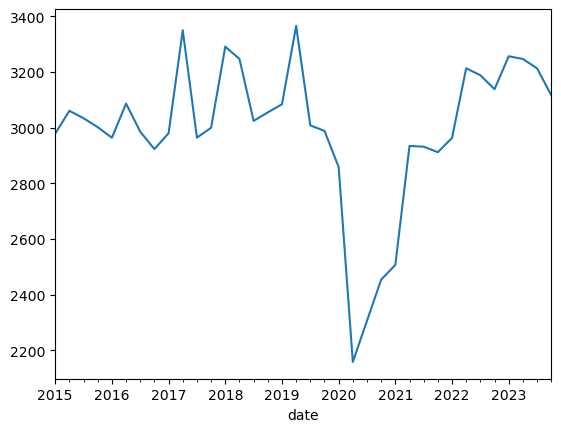

In [98]:
data['RGDP0000'].dropna().plot()